# Clustering de clientes mayoristas con K-Means
### Nombre del alumno: **Miguel Angel Moran Flores**
### Nombre del producto: **K-means**
### Objetivo General:
* Aplicar el algoritmo K-Means para segmentación de clientes.
* Utilizar el método del codo para determinar el número óptimo de clusters.
* Visualizar resultados de clustering en espacios 2D.
* Generar perfiles de clientes basados en análisis no supervisado.
### Introducción: **Se realiza clusterizacion para el dataset wholesale buscando el mas optimo** 

In [276]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Fase 1

## Actividad 1.1

In [277]:
df=pd.read_csv("data/Wholesale_customers_data.csv")

Explora la estructura del dataset:

In [278]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [279]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [280]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [281]:
df.max() - df.min()

Channel                  1
Region                   2
Fresh               112148
Milk                 73443
Grocery              92777
Frozen               60844
Detergents_Paper     40824
Delicassen           47940
dtype: int64

In [282]:
df.std().idxmax()

'Fresh'

# Preguntas guía
¿Cuántos clientes hay en el dataset? **440**

¿Hay valores faltantes? ¿Cómo los tratarías? **No, Imputar con media o mediana**

¿Cuál es el rango de gasto en cada categoría?
* Fresh:               112148
* Milk:                 73443
* Grocery:              92777
* Frozen:               60844
* Detergents_Paper:     40824
* Delicassen:           47940

¿Qué categoría tiene mayor variabilidad? **Fresh**

## Actividad 1.2

In [283]:
df=df.iloc[:,2:8]

In [284]:
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [285]:
escalator = MinMaxScaler().fit(df.values)
df_scaled = escalator.transform(df.values)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.112940,0.130727,0.081464,0.003106,0.065427,0.027847
1,0.062899,0.132824,0.103097,0.028548,0.080590,0.036984
2,0.056622,0.119181,0.082790,0.039116,0.086052,0.163559
3,0.118254,0.015536,0.045464,0.104842,0.012346,0.037234
4,0.201626,0.072914,0.077552,0.063934,0.043455,0.108093


In [286]:
print(df_scaled.mean())
print(df_scaled.std())

Fresh               0.106977
Milk                0.078173
Grocery             0.085671
Frozen              0.050078
Detergents_Paper    0.070510
Delicassen          0.031745
dtype: float64
Fresh               0.112774
Milk                0.100491
Grocery             0.102430
Frozen              0.079789
Detergents_Paper    0.116790
Delicassen          0.058826
dtype: float64


# Preguntas guía:

¿Por qué es importante normalizar antes de K-Means? **Porque K-Means usa distancia euclidiana para formar los clusters. Si las variables están en escalas diferentes, las que tienen valores más grandes dominan el cálculo de distancia y sesgan el clustering.**

¿Qué sucedería si no normalizas? **K-Means se vuelve sesgado hacia variables con valores grandes.**

¿Cómo verificas que la normalización fue exitosa? **Se verifica revisando que los datos normalizados tengan media cercana a 0 y valores entre 0 y 1.**


# Fase 2

## Actividad 2.1

In [287]:
inertias = []
K = range(2, 12)
for i in K:
    kmeans= KMeans(n_clusters=i, random_state=42).fit(df_scaled.values)
    inertias.append(kmeans.inertia_)
    print(f"Inercia: {kmeans.inertia_} para K = {i}")


Inercia: 21.036183583781295 para K = 2
Inercia: 13.894651794694095 para K = 3
Inercia: 10.766660398385048 para K = 4
Inercia: 9.232739455291759 para K = 5
Inercia: 8.865010150451786 para K = 6
Inercia: 7.9163538474826725 para K = 7
Inercia: 6.896866260181024 para K = 8
Inercia: 6.302895924195356 para K = 9
Inercia: 5.6230097425640775 para K = 10
Inercia: 5.274241316868544 para K = 11


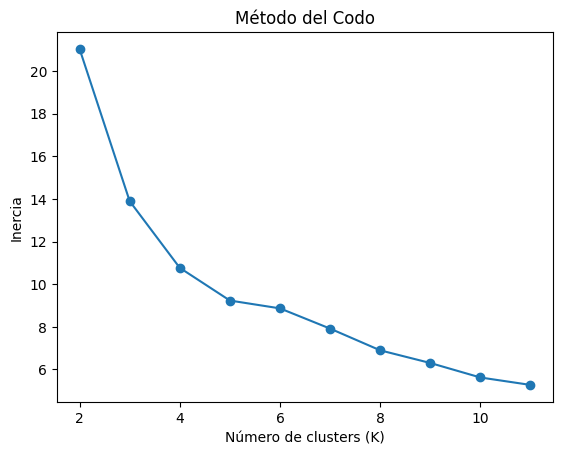

In [288]:
plt.plot(K, inertias, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo")

plt.show()

In [289]:
k_opt = 4

In [290]:
k3 = KMeans(n_clusters=3, random_state=42).fit(df_scaled.values)
k5 = KMeans(n_clusters=5, random_state=42).fit(df_scaled.values)
k_opt_model = KMeans(n_clusters=k_opt, random_state=42).fit(df_scaled.values)

In [291]:
print("Inercia K=3:", k3.inertia_)
print("Inercia K=5:", k5.inertia_)
print("Inercia K óptimo:", k_opt_model.inertia_)

Inercia K=3: 13.894651794694095
Inercia K=5: 9.232739455291759
Inercia K óptimo: 10.766660398385048


In [292]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled.values)

K = 3

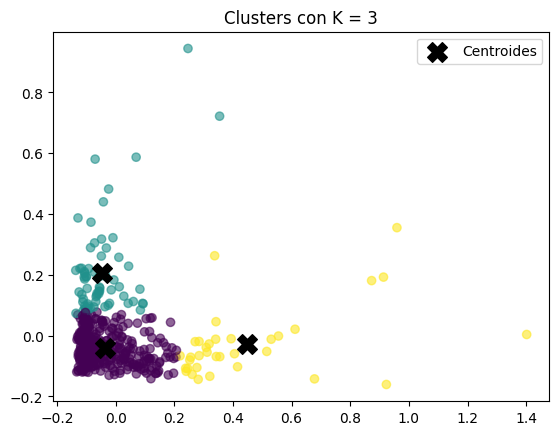

In [293]:
centroides_pca = pca.transform(k3.cluster_centers_)
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=k3.labels_, alpha=0.6)
plt.scatter(
    centroides_pca[:,0],
    centroides_pca[:,1],
    marker="X",
    s=200,
    color="black",
    label="Centroides"
)
plt.title("Clusters con K = 3")
plt.legend()
plt.show()

K = 5

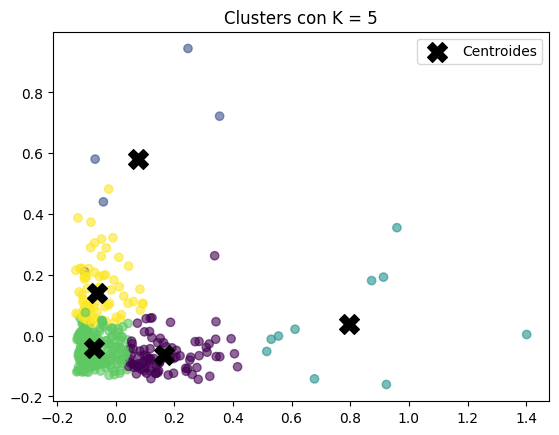

In [294]:
centroides_pca = pca.transform(k5.cluster_centers_)
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=k5.labels_, alpha=0.6)
plt.scatter(
    centroides_pca[:,0],
    centroides_pca[:,1],
    marker="X",
    s=200,
    color="black",
    label="Centroides"
)
plt.title("Clusters con K = 5")
plt.legend()
plt.show()

K óptimo: 4

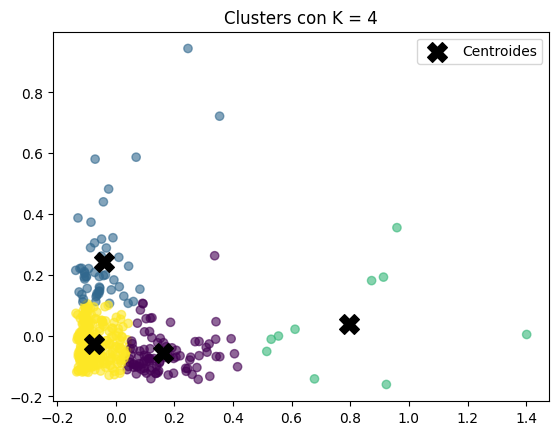

In [295]:
centroides_pca = pca.transform(k_opt_model.cluster_centers_)
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=k_opt_model.labels_, alpha=0.6)
plt.scatter(
    centroides_pca[:,0],
    centroides_pca[:,1],
    marker="X",
    s=200,
    color="black",
    label="Centroides"
)
plt.title("Clusters con K = 4")
plt.legend()
plt.show()

# Preguntas guía:
¿En qué valor de K observas el "codo"? **K=4**

¿Cuál es la diferencia de inercia entre K=3 y K=4? **Se vuelven mas compactos los clusters cercanos**

¿Por qué la inercia siempre disminuye al aumentar K? **Porque al aumentar K hay más centroides y los puntos quedan más cerca de alguno, reduciendo la suma de distancias dentro de los clusters**

¿Cuál es el trade-off entre precisión y simplicidad? **Más K reduce la inercia y mejora la precisión, pero hace el modelo más complejo; menos K simplifica el modelo pero produce clusters menos precisos.**

## Actividad 2.2

In [296]:
resultados = []

for k in [3,4,5]:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(df_scaled.values)
    conteo = pd.Series(kmeans.labels_).value_counts().sort_index()

    resultados.append({
        "K": k,
        "Inercia": kmeans.inertia_,
        "Cluster 0": conteo.get(0,0),
        "Cluster 1": conteo.get(1,0),
        "Cluster 2": conteo.get(2,0),
        "Cluster 3": conteo.get(3,0),
        "Cluster 4": conteo.get(4,0)
    })

tabla = pd.DataFrame(resultados)

tabla

,K,Inercia,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
0,3,13.894652,336,70,34,0,0
1,4,10.766660,93,52,10,285,0
2,5,9.232739,89,6,10,248,87


# Fase 3:
## Actividad 3.1

In [297]:
df_scaled.columns

Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'], dtype='object')

In [298]:
colores = ["red", "green", "blue", "orange", "brown", "pink", "cyan", "magenta"]
df_scaled['cluster']=k_opt_model.labels_

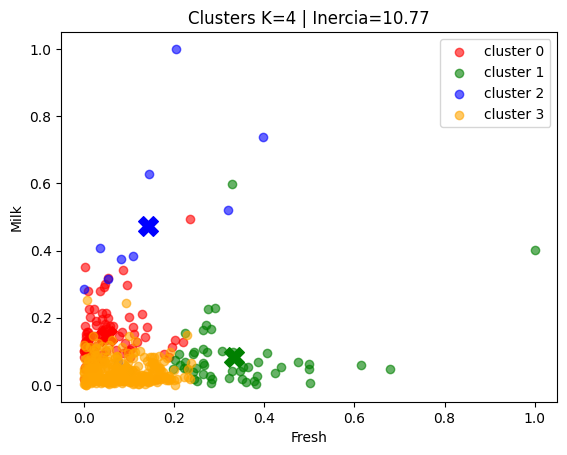

In [299]:

for i in range(k_opt_model.n_clusters):

    cluster_data = df_scaled[df_scaled["cluster"] == i]

    plt.scatter(
        cluster_data["Fresh"],
        cluster_data["Milk"],
        color=colores[i],
        label=f"cluster {i}",
        alpha=0.6
    )

    plt.scatter(
        k_opt_model.cluster_centers_[i,0],
        k_opt_model.cluster_centers_[i,1],
        color=colores[i],
        marker="X",
        s=200
    )

plt.xlabel("Fresh")
plt.ylabel("Milk")

plt.legend()
plt.title(f"Clusters K={k_opt_model.n_clusters} | Inercia={k_opt_model.inertia_:.2f}")

plt.show()

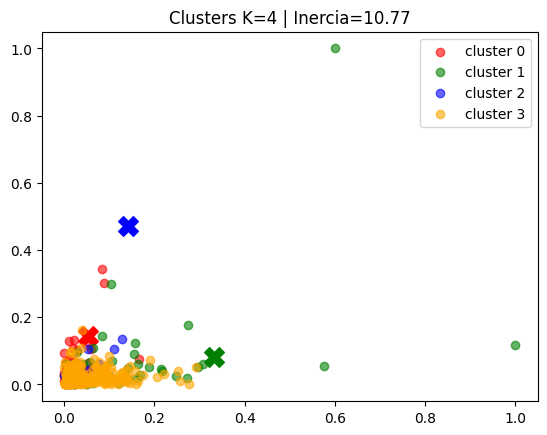

In [300]:
for i in range(k_opt_model.n_clusters):

    cluster_data = df_scaled[df_scaled["cluster"] == i]

    plt.scatter(
        cluster_data["Frozen"],
        cluster_data["Delicassen"],
        color=colores[i],
        label=f"cluster {i}",
        alpha=0.6
    )

    plt.scatter(
        k_opt_model.cluster_centers_[i,0],
        k_opt_model.cluster_centers_[i,1],
        color=colores[i],
        marker="X",
        s=200
    )

cluster_data["Frozen"],
cluster_data["Delicassen"],

plt.legend()
plt.title(f"Clusters K={k_opt_model.n_clusters} | Inercia={k_opt_model.inertia_:.2f}")

plt.show()

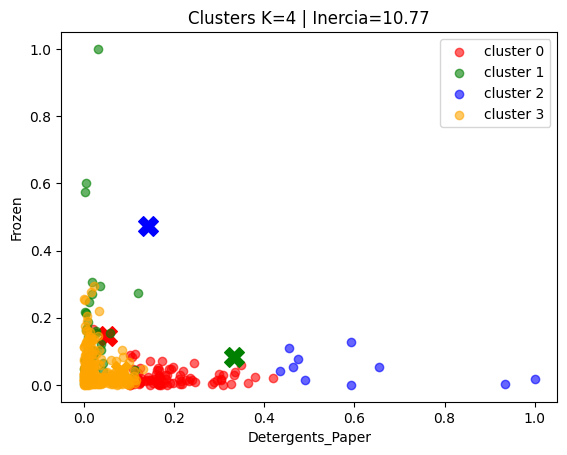

In [301]:
for i in range(k_opt_model.n_clusters):

    cluster_data = df_scaled[df_scaled["cluster"] == i]

    plt.scatter(
        cluster_data["Detergents_Paper"],
        cluster_data["Frozen"],
        color=colores[i],
        label=f"cluster {i}",
        alpha=0.6
    )

    plt.scatter(
        k_opt_model.cluster_centers_[i,0],
        k_opt_model.cluster_centers_[i,1],
        color=colores[i],
        marker="X",
        s=200
    )

plt.xlabel("Detergents_Paper")
plt.ylabel("Frozen")

plt.legend()
plt.title(f"Clusters K={k_opt_model.n_clusters} | Inercia={k_opt_model.inertia_:.2f}")
plt.show()

# Conclucion:
Los clusters muestran distintos patrones de consumo entre categorías. Algunos grupos presentan altos niveles de compras en productos de supermercado como grocery y detergents, mientras que otros se concentran en productos frescos o congelados. Esto sugiere que los clusters pueden representar diferentes tipos de clientes, como restaurantes, minoristas o compradores especializados.